# Chromatin Loops Heterogeneity

This notebook analyzes the heterogeneity of chromatin loops using Jaccard similarity and clustering approaches.

In [ ]:
import pandas as pdfrom scipy.spatial.distance import pdist, squareformfrom scipy.cluster.hierarchy import fclusterdataimport numpy as npfrom sklearn.cluster import DBSCANfrom os import listdirfrom tqdm import tqdmimport matplotlib.pyplot as pltfrom intervaltree import Interval, IntervalTreefrom collections import Counterfrom itertools import chainfrom itertools import combinationsimport osimport globimport jsonimport timeimport seaborn as snsimport coolerimport bioframeimport cooltoolsfrom cooltools.lib.numutils import fill_diagfrom statsmodels.stats.multitest import multipletestsfrom os.path import isfile, join, basenamefrom io import StringIOimport picklefrom concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutorimport warningsfrom scipy.stats import mannwhitneyufrom dotenv import load_dotenvload_dotenv()assert os.environ['CONDA_DEFAULT_ENV'] == "hic"
import pybedtools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib as mpl
from itertools import combinations
import scipy.stats as stats

# Chromatin Loops Heterogeneity

This notebook analyzes the heterogeneity of chromatin loops using Jaccard similarity and clustering approaches.

In [2]:
path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")path_to_loops = "/tank/projects/diana_hic/sz_project2024/2.loops_calling/loops_cooltools_data/"path_to_maps_expected = "../0.additional_data/expected_maps/"path_to_loops_clusters_data = "/tank/projects/diana_hic/sz_project2024/2.loops_calling//loops_cooltools_data_noSexChromosomes/loops_clusters_data_15kb"

In [6]:
samples = ['HC-2Mplus', 'HC-318plus', 'HC-3Mplus', 'HC-91plus', 'HC24plus', 'HCM12plus', 'SZ-01plus', 'SZ-03plus', 'SZ08plus', 'SZ10plus', 'SZ20plus', 'SZ6plus']path_to_loops_intensities_noSexChromosomes = "./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/"loops = {}for sample in samples:    df= pd.read_csv(f"{path_to_loops_intensities_noSexChromosomes}/{sample}_20kb_cooltools_loops_sorted_with_intensity.bed", sep='\t')    loops[sample] = df

In [64]:
hc_samples = ['HC-2Mplus', 'HC-318plus', 'HC-3Mplus', 'HC-91plus', 'HC24plus', 'HCM12plus']sz_samples=[            'SZ-01plus', 'SZ-03plus', 'SZ08plus', 'SZ10plus', 'SZ20plus', 'SZ6plus']def slop_bedpe(df, slop=22500):    """Extend both anchors of BEDPE by ±slop."""    df = df.copy()    df['start1'] = df['start1'] - slop    df['end1'] = df['end1'] + slop    df['start2'] = df['start2'] - slop    df['end2'] = df['end2'] + slop    # Ensure start >= 0    df['start1'] = df['start1'].clip(lower=0)    df['start2'] = df['start2'].clip(lower=0)    return df    path_to_loops_intensities_noSexChromosomes = "/./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/"all_files = []for sample in samples:    df= pd.read_csv(f"{path_to_loops_intensities_noSexChromosomes}/{sample}_20kb_cooltools_loops_sorted_with_intensity.bed", sep='\t')    fname = f"{path_to_loops_intensities_noSexChromosomes}/{sample}_20kb_cooltools_loops_slopped1.5.bedpe"    df[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].to_csv(fname, sep='\t', header=False, index=False)    df=slop_bedpe(df)    all_files.append(fname)hc_files = []for sample in hc_samples:    df= pd.read_csv(f"{path_to_loops_intensities_noSexChromosomes}/{sample}_20kb_cooltools_loops_sorted_with_intensity.bed", sep='\t')    fname = f"{path_to_loops_intensities_noSexChromosomes}/{sample}_20kb_cooltools_loops_slopped1.5.bedpe"    df[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].to_csv(fname, sep='\t', header=False, index=False)    df=slop_bedpe(df)    hc_files.append(fname)sz_files = []for sample in sz_samples:    df= pd.read_csv(f"{path_to_loops_intensities_noSexChromosomes}/{sample}_20kb_cooltools_loops_sorted_with_intensity.bed", sep='\t')    fname = f"{path_to_loops_intensities_noSexChromosomes}/{sample}_20kb_cooltools_loops_slopped1.5.bedpe"    df[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].to_csv(fname, sep='\t', header=False, index=False)    df=slop_bedpe(df)    sz_files.append(fname)        

In [7]:
path_to_maps = "/tank/projects/kmorozov/SZ_check_pol/"path_to_maps_expected = "/tank/projects/diana_hic/sz_project2024/1.main_data/expected_maps_res15kb/"save_name = "loops_SZ_vs_Healthy"pattern = "_noHeader"name_appender=''merged_all_clusters = pd.read_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")merged_all_clusters['short_name_for_plot'] = [i.split('plus_20kb') [0] for i in merged_all_clusters.source]df = merged_all_clusters[['short_name_for_plot','cluster','intensity_median']].drop_duplicates()pivot_df = df.pivot(index='cluster', columns='short_name_for_plot', values='intensity_median')correlation_matrix = pivot_df.corr()

In [25]:
def df_to_bedpe(df, fname):    """Save DataFrame to BEDPE file (6 columns)."""    df[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].to_csv(fname, sep='\t', header=False, index=False)

In [30]:
def pair_jaccard_index(bedpe1, bedpe2):    """Compute Jaccard index for two BEDPE files using pybedtools."""    A = pybedtools.BedTool(bedpe1)    B = pybedtools.BedTool(bedpe2)    intersect = A.pair_to_pair(B, slop=22500, type='either', is_sorted=False)    overlap_loops = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in intersect)    loops_A = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in A)    loops_B = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in B)    union_loops = loops_A | loops_B    if len(union_loops) == 0:        return 0    return len(overlap_loops) / len(union_loops)

In [27]:
def group_jaccard_indices(bedpe_files):    """Compute all pairwise Jaccard indices for a list of BEDPE files."""    results = []    for f1, f2 in combinations(bedpe_files, 2):        jaccard = pair_jaccard_index(f1, f2)        results.append({'file1': f1, 'file2': f2, 'jaccard': jaccard})    return pd.DataFrame(results)

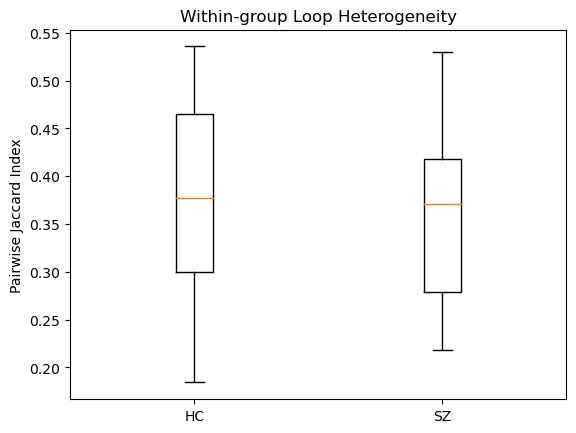

In [31]:
bedpe_files = {}for sample in samples:    df = loops[sample]    df_slopped = slop_bedpe(df, slop=22500)    bedpe_path = os.path.join(slop_bedpe_dir, f"{sample}.bedpe")    df_to_bedpe(df_slopped, bedpe_path)    bedpe_files[sample] = bedpe_pathhc_samples = [s for s in samples if s.startswith('HC')]sz_samples = [s for s in samples if s.startswith('SZ')]hc_bedpe_files = [bedpe_files[s] for s in hc_samples]sz_bedpe_files = [bedpe_files[s] for s in sz_samples]hc_jaccard_df = group_jaccard_indices(hc_bedpe_files)sz_jaccard_df = group_jaccard_indices(sz_bedpe_files)plt.boxplot([hc_jaccard_df['jaccard'], sz_jaccard_df['jaccard']],            labels=['HC', 'SZ'])plt.ylabel('Pairwise Jaccard Index')plt.show()

In [65]:
def extract_sample_name(filename):    """    Extracts sample name from filename.    Example: 'tad_borders_HC-2Mplus_sampled_drop_diag_15res_150wind.bed' -> '2M'    """    match = filename.split('tad_borders_')[1].split('minus')[0]    if match:        return match    else:        return filenamedef set_jaccard(bedpe1, bedpe2, slop=0):    """Compute Jaccard index for two BEDPE files using pybedtools."""    A = pybedtools.BedTool(bedpe1)    B = pybedtools.BedTool(bedpe2)    intersect = A.pair_to_pair(B, slop=slop, type='either', is_sorted=False)    overlap_loops = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in intersect)    loops_A = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in A)    loops_B = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in B)    union_loops = loops_A | loops_B    if len(union_loops) == 0:        return 0    return len(overlap_loops) / len(union_loops)    def pairwise_set_jaccard(bed_files):    n = len(bed_files)    matrix = np.zeros((n, n))    for i in range(n):        for j in range(n):            if i <= j:                jac = set_jaccard(bed_files[i], bed_files[j])                matrix[i, j] = jac                matrix[j, i] = jac      return matrix

In [67]:
hc_matrix = pairwise_set_jaccard(hc_files)sz_matrix = pairwise_set_jaccard(sz_files)all_matrix = pairwise_set_jaccard(all_files)

In [77]:
samples_with_age = {    'HC-2M': 62,    'HC-3M': 36,    'HC-91': 59,    'HC24': 54,    'HC-318': 58,    'HCM12': 35,    'SZ-01': 36,    'SZ-03': 57,    'SZ08': 56,    'SZ10': 50,    'SZ20': 37,    'SZ6': 62}age_group = {}for label, age in samples_with_age.items():    if age <= 40:        age_group[label] = "Adult"    elif 40 < age <= 57:        age_group[label] = "Old"    else:        age_group[label] = "Old"def extract_sample_name(filename):       try:        core = filename.split('plus')[0]        core = core.rstrip('_')        return core    except:        print(filename)def get_sorted_labels_and_indices(labels, samples_with_age):    paired = [(label, samples_with_age[label]) for label in labels]    paired_sorted = sorted(paired, key=lambda x: x[1])    sorted_labels = [p[0] for p in paired_sorted]    sorted_indices = [labels.index(lab) for lab in sorted_labels]    return sorted_labels, sorted_indicesdef make_label(label):    age = samples_with_age[label]    group = age_group[label]    short = label    return f"{short}\n{age}y\n{group}"def plot_heatmap(matrix, labels, title, samples_with_age, figsize=(6, 5)):    sns.set_theme(style='ticks')    sorted_labels, sorted_indices = get_sorted_labels_and_indices(labels, samples_with_age)    sorted_matrix = matrix[np.ix_(sorted_indices, sorted_indices)]    annotated_labels = [make_label(lab) for lab in sorted_labels]    df = pd.DataFrame(sorted_matrix, index=annotated_labels, columns=annotated_labels)    min_val = np.min(sorted_matrix)    max_val = 0.4    plt.figure(figsize=figsize)    sns.heatmap(        df,        annot=True,        cmap='YlGnBu',        vmin=min_val,        vmax=max_val,        square=True,        linewidths=0.5,        cbar_kws={"label": "Set-based Jaccard Index"}    )    plt.title(title, fontsize=16)    plt.yticks(rotation=0)    # plt.xticks(rotation=15, ha='right')    plt.tight_layout()    plt.show()hc_labels = [extract_sample_name(os.path.basename(f)) for f in hc_files]sz_labels = [extract_sample_name(os.path.basename(f)) for f in sz_files]all_labels = [extract_sample_name(os.path.basename(f)) for f in all_files]

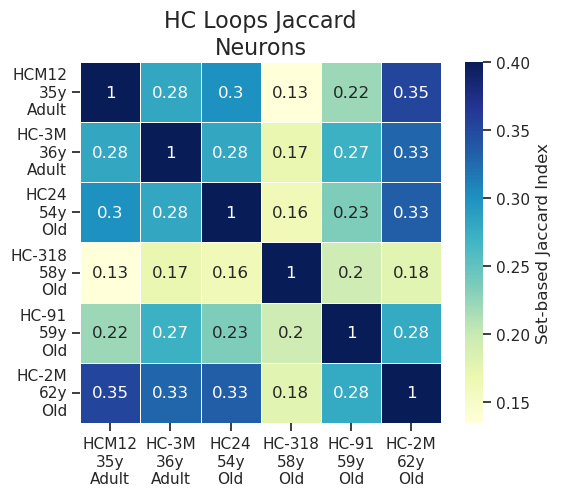

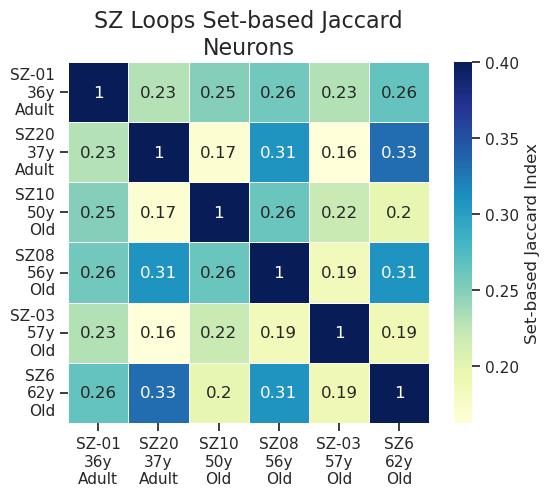

In [75]:
plot_heatmap(hc_matrix, hc_labels, 'HC Loops Jaccard\nNeurons', samples_with_age)plot_heatmap(sz_matrix, sz_labels, 'SZ Loops Set-based Jaccard\nNeurons', samples_with_age)

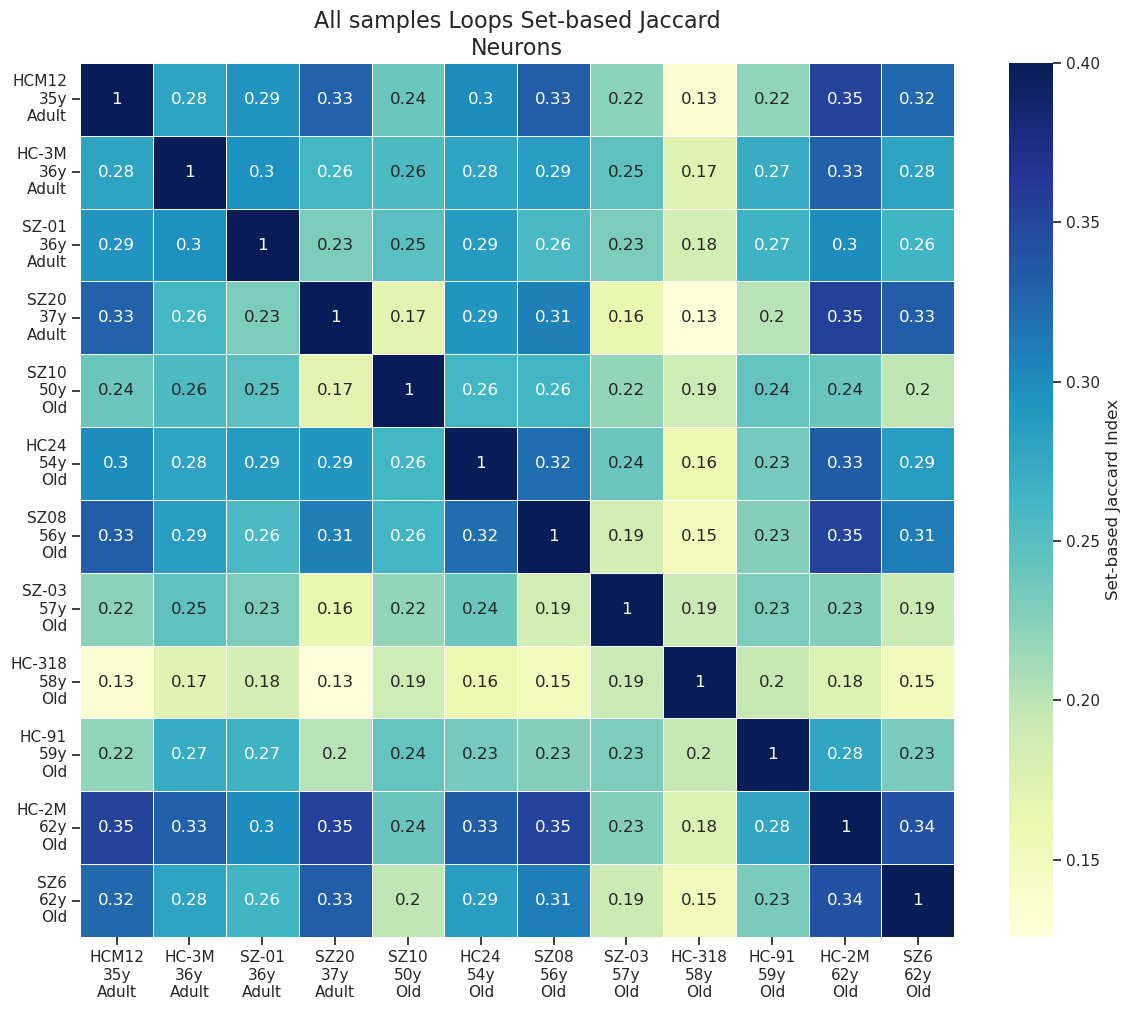

In [78]:
plot_heatmap(all_matrix, all_labels, 'All samples Loops Set-based Jaccard\nNeurons', samples_with_age, figsize=(12, 10))

## Box plots

In [118]:
def get_group(label):    if label.startswith('HC'):        return 'HC'    elif label.startswith('SZ'):        return 'SZ'    else:        return 'Other'def significance_label(p):    if p < 0.001:        return '***'    elif p < 0.01:        return '**'    elif p < 0.05:        return '*'    else:        return 'ns'all_matrix_set = all_matrix.copy()all_labels_set = all_labels.copy()groups = [get_group(label) for label in all_labels_set]

In [120]:
data = []n = len(all_labels_set)for i in range(n):    for j in range(i+1, n):        sim = all_matrix_set[i, j]        group_i = groups[i]        group_j = groups[j]        if group_i == group_j == 'HC':            cat = 'Within HC'        elif group_i == group_j == 'SZ':            cat = 'Within SZ'        elif (group_i == 'HC' and group_j == 'SZ') or (group_i == 'SZ' and group_j == 'HC'):            cat = 'Between HC-SZ'        else:            continue        data.append({'similarity': sim, 'category': cat})df = pd.DataFrame(data)order = ['Within HC', 'Within SZ', 'Between HC-SZ']

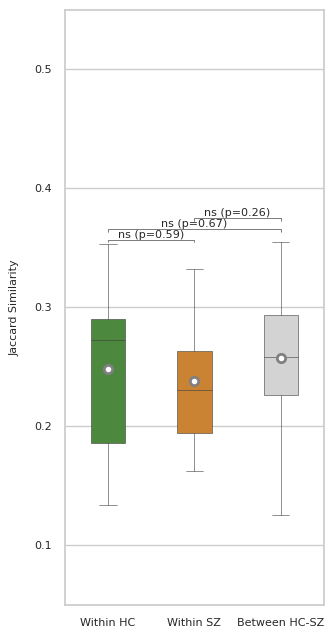

In [133]:
my_pal = {    "Within HC": '#469433',    "Within SZ":  '#e38519',    "Between HC-SZ": "lightgrey"}cat_labels = ['Within HC', 'Within SZ', 'Between HC-SZ']pvals = {}for cat1, cat2 in combinations(cat_labels, 2):    group1 = df[df['category'] == cat1]['similarity']    group2 = df[df['category'] == cat2]['similarity']    stat, pval = mannwhitneyu(group1, group2, alternative='two-sided')    pvals[(cat1, cat2)] = pvalsns.set(style="whitegrid")mpl.rcParams['font.family'] = 'Arial'mpl.rcParams['axes.titlesize'] = 8mpl.rcParams['axes.labelsize'] = 8mpl.rcParams['xtick.labelsize'] = 8mpl.rcParams['ytick.labelsize'] = 8plt.rcParams["svg.fonttype"] = "none"plt.figure(figsize=( 3.5, 6.54))ax = sns.boxplot(    x='category', y='similarity', data=df, order=order,    palette=my_pal, showfliers=False, linewidth=0.4, width=0.4,    showmeans=True,    meanprops={        "marker": "o",        "markerfacecolor": "white",        "markeredgecolor": "grey",        "markersize": 6,        "markeredgewidth": 2    })ax.set_xlabel('')ax.set_ylabel('Jaccard Similarity', labelpad=10)ax.set_ylim(0.05, 0.55)y_max = df['similarity'].max()y_min = df['similarity'].min()# y_min=0.1h = (y_max - y_min) * 0.04  pairs = [    (0, 1),  # Within HC vs Within SZ    (0, 2),  # Within HC vs Between    (1, 2)   # Within SZ vs Between]for idx, ((cat1, cat2), (i, j)) in enumerate(zip(pvals.keys(), pairs)):    y = y_max + h*idx    x1, x2 = i, j    pval = pvals[(cat1, cat2)]    label = significance_label(pval) + f" (p={round(pval,2)})"    # Line    ax.plot([x1, x1, x2, x2], [y, y+h/4, y+h/4, y], lw=0.4, c='k')    # Text    ax.text((x1+x2)/2, y+h/4, label, ha='center', va='bottom', fontsize=8)plt.tight_layout()cell_type = "neurons"plt.savefig(f'./loops_visualizations/loops_{cell_type}_jaccard_similarity_groups_pubready.svg', dpi=300)plt.savefig(f'./loops_visualizations/loops_{cell_type}_jaccard_similarity_groups_pubready.pdf', dpi=300)plt.show()

## Clustergram

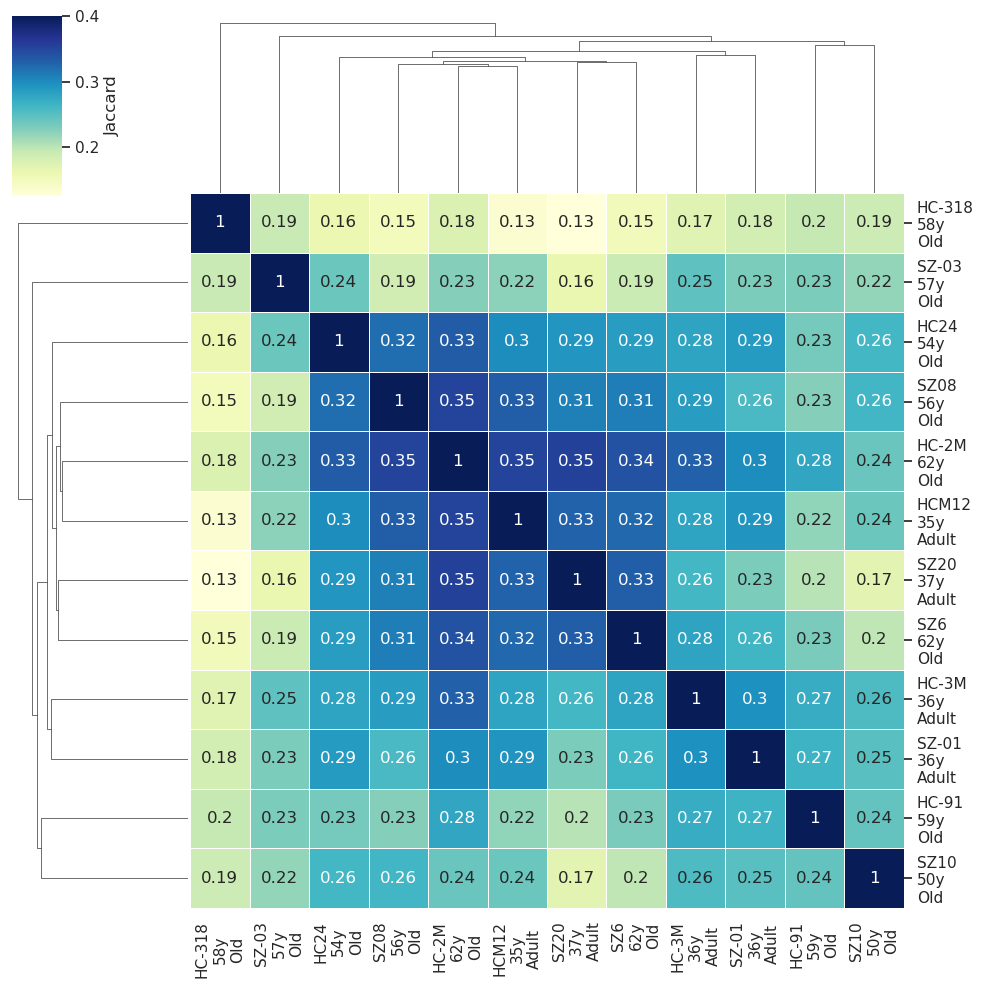

In [104]:
def make_label(label):    age = samples_with_age[label]    group = age_group[label]    short = label    return f"{short}\n{age}y\n{group}"def plot_clustermap(matrix, labels, title, samples_with_age, figsize=(8, 8)):    annotated_labels = [make_label(lab) for lab in labels]    distance_matrix = matrix    sorted_labels, sorted_indices = get_sorted_labels_and_indices(labels, samples_with_age)    sorted_matrix = matrix[np.ix_(sorted_indices, sorted_indices)]    min_val = np.min(sorted_matrix)    max_val = 0.4    df = pd.DataFrame(distance_matrix, index=annotated_labels, columns=annotated_labels)    cg = sns.clustermap(        df,        cmap='YlGnBu',        linewidths=0.5,        figsize=figsize,        vmin=min_val,        vmax=max_val,        annot=True,        cbar_kws={"label": "Jaccard"},        metric='euclidean',        method='average',        # col_cluster=False  # Only cluster rows, not columns    )    # plt.suptitle(title, fontsize=16)    plt.show()plot_clustermap(all_matrix, all_labels, 'All samples Loops Set-based Jaccard\nNeurons', samples_with_age, figsize=(10, 10))

In [112]:
def get_off_diagonal(matrix):    n = matrix.shape[0]    return [matrix[i, j] for i in range(n) for j in range(n) if i != j]

Mann-Whitney U statistic: 504.000
p-value: 4.288e-01
HC mean: 0.248, median: 0.272
SZ mean: 0.238, median: 0.231


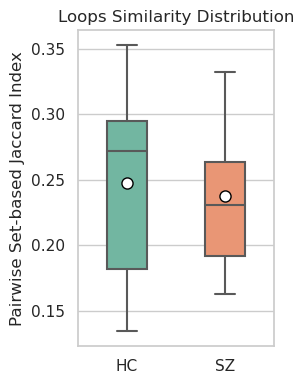

In [113]:
hc_similarities = get_off_diagonal(hc_matrix)sz_similarities = get_off_diagonal(sz_matrix)stat, p_value = mannwhitneyu(hc_similarities, sz_similarities, alternative='two-sided')print(f"Mann-Whitney U statistic: {stat:.3f}")print(f"p-value: {p_value:.3e}")print(f"HC mean: {np.mean(hc_similarities):.3f}, median: {np.median(hc_similarities):.3f}")print(f"SZ mean: {np.mean(sz_similarities):.3f}, median: {np.median(sz_similarities):.3f}")plt.figure(figsize=(3, 4))sns.boxplot(    data=[hc_similarities, sz_similarities],        width=0.4,    palette='Set2',    showmeans=True,    meanprops={        "marker": "o",        "markerfacecolor": "white",        "markeredgecolor": "black",        "markersize": "8"    })plt.xticks([0, 1], ['HC', 'SZ'])plt.ylabel('Pairwise Set-based Jaccard Index')plt.title('Loops Similarity Distribution')plt.tight_layout()plt.show()

In [95]:
def pairwise_similarity_df(matrix, labels):    data = []    n = len(labels)    for i in range(n):        for j in range(i+1, n):  # i != j, only upper triangle            sim = matrix[i, j]            label_i, label_j = labels[i], labels[j]            group_i, group_j = get_group(label_i), get_group(label_j)            age_i, age_j = age_group[label_i], age_group[label_j]            data.append({                'sample1': label_i, 'sample2': label_j,                'group1': group_i, 'group2': group_j,                'age_group1': age_i, 'age_group2': age_j,                'similarity': sim            })    return pd.DataFrame(data)def get_group(label):    if label.startswith('HC'):        return 'HC'    elif label.startswith('SZ'):        return 'SZ'    else:        return 'Unknown'        samples_with_age = {    'HC-2M': 62, 'HC-3M': 36, 'HC-91': 59, 'HC24': 54, 'HC-318': 58, 'HCM12': 35,    'SZ-01': 36, 'SZ-03': 57, 'SZ08': 56, 'SZ10': 50, 'SZ20': 37, 'SZ6': 62}age_group = {}for label, age in samples_with_age.items():    if age <= 40:        age_group[label] = "Adult"    elif 40 < age <= 57:        age_group[label] = "Old"    else:        age_group[label] = "Old"        hc_df = pairwise_similarity_df(hc_matrix, hc_labels)sz_df = pairwise_similarity_df(sz_matrix, sz_labels)all_df = pd.concat([hc_df, sz_df], ignore_index=True)

In [96]:
age_comparison = ['Adult-Old', 'Old-Old', 'Adult-Adult']all_df['comparison'] = all_df['age_group1'] + all_df['age_group2']age_comparison_list = []for i in all_df['comparison']:    if "Adult" in i and "Old" in i:        age_comparison_list.append('Adult-Old')    elif "Adult" in i and "Old" not in i:        age_comparison_list.append('Adult-Adult')    else:        age_comparison_list.append('Old-Old')all_df['comparison'] = age_comparison_listall_df['group'] = all_df['group2']

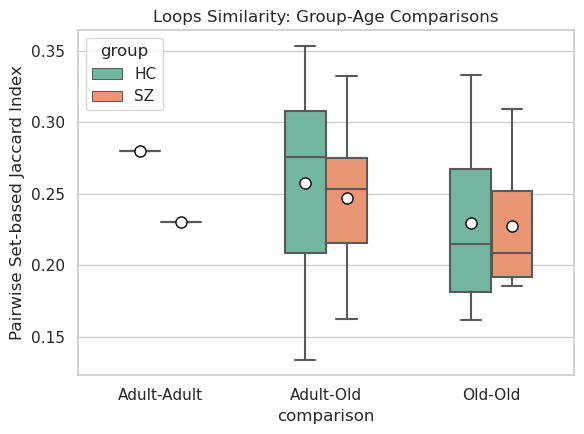

In [106]:
sns.set(style="whitegrid")plt.figure(figsize=(6, 4.5))sns.boxplot(    data=all_df,    x=all_df.comparison,    y=all_df.similarity,    hue = "group",    order = [ 'Adult-Adult','Adult-Old', 'Old-Old'],    showmeans=True,    meanprops={        "marker": "o",        "markerfacecolor": "white",        "markeredgecolor": "black",        "markersize": "8"    },    width=0.5,    palette='Set2')plt.ylabel('Pairwise Set-based Jaccard Index')plt.title('Loops Similarity: Group-Age Comparisons')plt.tight_layout()plt.show()

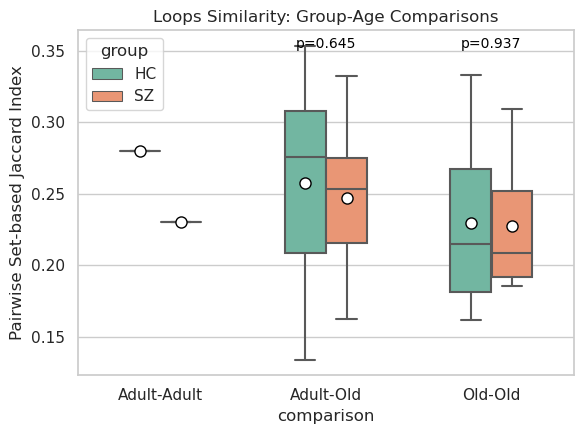

In [111]:
plt.figure(figsize=(6, 4.5))ax = sns.boxplot(    data=all_df,    x="comparison",    y="similarity",    hue="group",    order=['Adult-Adult', 'Adult-Old', 'Old-Old'],    showmeans=True,    meanprops={        "marker": "o",        "markerfacecolor": "white",        "markeredgecolor": "black",        "markersize": "8"    },    width=0.5,    palette='Set2')plt.ylabel('Pairwise Set-based Jaccard Index')plt.title('Loops Similarity: Group-Age Comparisons')plt.tight_layout()# --- Statistical test and annotation ---hue_order = all_df["group"].unique()x_order = ['Adult-Adult', 'Adult-Old', 'Old-Old']for i, x_val in enumerate(x_order):    data = all_df[all_df['comparison'] == x_val]    groups = data['group'].unique()    if len(groups) < 2:        continue    vals = []    for g in groups:        vals.append(data[data['group'] == g]['similarity'].values)    # Only do test if both groups have at least 2 points    if all([len(v) >= 2 for v in vals]):        stat, pval = stats.mannwhitneyu(vals[0], vals[1], alternative='two-sided')        # Annotate p-value above the box        y_max = max([np.max(v) if len(v) > 0 else 0 for v in vals])        y_min = min([np.min(v) if len(v) > 0 else 0 for v in vals])        y = 0.35        ax.text(i, y, f"p={pval:.3f}", ha='center', va='bottom', fontsize=10, color='black')plt.show()